# Blazar Population ML — Project 1

**Goal:** Apply classical ML to the 4LAC-DR3 blazar catalog to recover constraints on jet baryon loading ($\mu$) from multi-wavelength observational features, and to characterize the blazar population via unsupervised clustering.

**Reference:** Rueda-Becerril, Harrison & Giannios (2021, MNRAS 501, 4092)

**Catalogs:**
- 4LAC-DR3: Ajello et al. (2022, arXiv:2209.12070), high-latitude, $|b| > 10^\circ$, `table-4LAC-DR3-h.fits`
- MOJAVE-XVII: apparent velocities from VLBI monitoring, `VizieR-MOJAVE-XVII.fit`

---

## Analysis Structure

- **Part 1 (full catalog, ~3,400 sources):** catalog-native features only, no kinematics
- **Part 2 (MOJAVE cross-matched, ~334 sources):** adds $\beta_{\text{app}}$ and $\Gamma_{\text{min}}$

**Notebook sections:**
1. Setup and imports
2. Load and inspect 4LAC-DR3
3. Load and inspect MOJAVE-XVII
4. Cross-match: 4LAC-DR3 × MOJAVE-XVII
5. Feature derivation and unified dataframes
6. Missingness audit
7. Exploratory data analysis (EDA)
8. Dimensionality reduction: PCA and UMAP
9. Clustering: GMM and HDBSCAN

## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from astropy.io import fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

# Cosmology (consistent with 2021 paper)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Paths
DATA_DIR = Path('data/')
LAC_H  = DATA_DIR / 'table-4LAC-DR3-h.fits'
MOJAVE = DATA_DIR / 'VizieR-MOJAVE-XVII.fit'

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
CLASS_COLORS = {'bll': 'steelblue', 'fsrq': 'tomato', 'bcu': 'gray'}
SED_COLORS   = {'lsp': 'tomato', 'isp': 'goldenrod', 'hsp': 'steelblue'}

## 2. Load and Inspect 4LAC-DR3

### Inspecting `table-4LAC-DR3-h.fits`

In [2]:
def safe_float(col):
    return np.ma.filled(col.data, np.nan).astype(float)

def safe_str(col):
    return np.array([str(v).strip() if v is not np.ma.masked else '' for v in col])

def safe_str_lower(col):
    return np.array([str(v).strip().lower() if v is not np.ma.masked else '' for v in col])

In [3]:
# Exploring header data units (HDUs)
with fits.open(LAC_H) as hdul:
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}: {type(hdu).__name__}")
        if hasattr(hdu, 'columns') and hdu.columns:
            print(f"Rows: {len(hdu.data)}")
            print(f"Columns ({len(hdu.columns)}):")
            for col in hdu.columns:
                print(f"  {col.name:30s}  {col.format:6s}  {col.unit if col.unit else ''}")

HDU 0: PrimaryHDU
HDU 1: BinTableHDU
Rows: 3407
Columns (41):
  Source_Name                     18A     
  DataRelease                     I       
  RAJ2000                         E       deg
  DEJ2000                         E       deg
  GLON                            E       deg
  GLAT                            E       deg
  Signif_Avg                      E       
  Flux1000                        E       ph cm-2 s-1
  Unc_Flux1000                    E       ph cm-2 s-1
  Energy_Flux100                  E       erg cm-2 s-1
  Unc_Energy_Flux100              E       erg cm-2 s-1
  SpectrumType                    18A     
  PL_Index                        E       
  Unc_PL_Index                    E       
  Pivot_Energy                    E       MeV
  LP_Index                        E       
  Unc_LP_Index                    E       
  LP_beta                         E       
  Unc_LP_beta                     E       
  Flags                           I       
  CLASS          

In [4]:
lac = Table.read(LAC_H)
lac_len = len(lac)

cls_mixed = safe_str(lac['CLASS'])
cls_lower = safe_str_lower(lac['CLASS'])
sed_arr = safe_str_lower(lac['SED_class'])

# Finding unique values in CLASS column
classes, cls_counts = np.unique(cls_lower, return_counts=True)
classes_mixed, counts_mixed = np.unique(cls_mixed, return_counts=True)

# Finding unique values in SED_class column
sed, sed_counts = np.unique(sed_arr, return_counts=True)

### `CLASS` distribution

In [5]:
for cl, n in sorted(zip(classes_mixed, counts_mixed), key=lambda x: -x[1]):
    print(f"{cl:10s}  {n:5d}  ({100 * n / lac_len:.1f}%)")

bll          1357  (39.8%)
bcu          1208  (35.5%)
fsrq          715  (21.0%)
FSRQ           40  (1.2%)
rdg            36  (1.1%)
BLL            22  (0.6%)
RDG             6  (0.2%)
agn             6  (0.2%)
css             5  (0.1%)
NLSY1           4  (0.1%)
nlsy1           4  (0.1%)
ssrq            2  (0.1%)
AGN             1  (0.0%)
sey             1  (0.0%)


### `SED_class` distribution

In [6]:
for s, n in sorted(zip(sed, sed_counts), key=lambda x: -x[1]):
    label = s if s else '(missing)'
    print(f"{label:10s}  {n:5d}  ({100 * n / lac_len:.1f}%)")

lsp          1564  (45.9%)
(missing)     777  (22.8%)
hsp           551  (16.2%)
isp           515  (15.1%)


### Missingness for key features

In [7]:
key_cols = [
    'PL_Index', 'LP_Index', 'Redshift', 'nu_syn', 'nuFnu_syn', 'HE_EPeak',
    'HE_nuFnuPeak', 'Variability_Index', 'Frac_Variability', 'Energy_Flux100'
]

for col in key_cols:
    arr = safe_float(lac[col])
    n_nan = np.sum(np.isnan(arr))
    n_zero = np.sum(arr == 0)
    print(f"{col:25s}  missing: {n_nan:4d} ({100 * n_nan / lac_len:5.1f}%)  zero: {n_zero:4d}")
    
print(f"\nN = {lac_len}")

PL_Index                   missing:    0 (  0.0%)  zero:    0
LP_Index                   missing:    0 (  0.0%)  zero:    0
Redshift                   missing:    0 (  0.0%)  zero:    0
nu_syn                     missing:    0 (  0.0%)  zero:  777
nuFnu_syn                  missing:    0 (  0.0%)  zero:  777
HE_EPeak                   missing:  518 ( 15.2%)  zero:    0
HE_nuFnuPeak               missing:    0 (  0.0%)  zero:    0
Variability_Index          missing:    0 (  0.0%)  zero:    0
Frac_Variability           missing:    0 (  0.0%)  zero:  874
Energy_Flux100             missing:    0 (  0.0%)  zero:    0

N = 3407


### Derived features feasibility

In [8]:
he_nufnu = safe_float(lac['HE_nuFnuPeak'])
nufnu_syn = safe_float(lac['nuFnu_syn'])
nu_syn = safe_float(lac['nu_syn'])
e_flux100 = safe_float(lac['Energy_Flux100'])
z = np.nan_to_num(lac['Redshift'].data, nan=0.0, posinf=0.0, neginf=0.0)

has_sed = (nufnu_syn > 0) & (he_nufnu > 0) & (~np.isnan(he_nufnu))
has_z = z > 0
has_lum = has_z & (e_flux100 > 0) & (~np.isnan(e_flux100))
has_cd = has_sed
is_blazar = np.isin(cls_lower, ['bll', 'fsrq'])
is_bcu = cls_lower == 'bcu'

### Compton Dominand and Gamma-ray Luminosity

In [9]:
cd_valid = np.sum(has_cd)
lum_valid = np.sum(has_lum)

print(f"Compton dominance computable:    {cd_valid:4d}/{lac_len}  ({100 * cd_valid / lac_len:.1f}%)")
print(f"Gamma-ray luminosity computable: {lum_valid:4d}/{lac_len}  ({100 * lum_valid / lac_len:.1f}%)")

Compton dominance computable:    2247/3407  (66.0%)
Gamma-ray luminosity computable: 1806/3407  (53.0%)


### Redshift

Redshift 0 means "no measurement", not actually z = 0.

In [10]:
print(f"z > 0 (measured):    {np.sum(z > 0):4d} ({100 * np.sum(z > 0) / lac_len:.1f}%)")
print(f"z = 0 (no redshift): {np.sum(z == 0):4d} ({100 * np.sum(z == 0) / lac_len:.1f}%)")

z > 0 (measured):    1806 (53.0%)
z = 0 (no redshift): 1601 (47.0%)


### `CLASS` case normalization issue

Mixed case entries detected: bll vs BLL, fsrq vs FSRQ; need normalization

In [11]:
for cl, n in sorted(zip(classes, cls_counts), key=lambda x: -x[1]):
    print(f"{cl:5s} + {cl.upper():5s} = {n:5d} ({100 * n / cls_counts.sum():.1f}%)")

bll   + BLL   =  1379 (40.5%)
bcu   + BCU   =  1208 (35.5%)
fsrq  + FSRQ  =   755 (22.2%)
rdg   + RDG   =    42 (1.2%)
nlsy1 + NLSY1 =     8 (0.2%)
agn   + AGN   =     7 (0.2%)
css   + CSS   =     5 (0.1%)
ssrq  + SSRQ  =     2 (0.1%)
sey   + SEY   =     1 (0.0%)


### BCU SED class breakdown

In [12]:
bcu_sed, bcu_counts = np.unique(sed_arr[is_bcu], return_counts=True)

for s, n in sorted(zip(bcu_sed, bcu_counts), key=lambda x: -x[1]):
    label = s if s else '(no SED class)'
    print(f"{label:15s}  {n:4d}")

lsp               508
(no SED class)    448
isp               135
hsp               117


### Confirmed blazars (BL Lacs + FSRQs) by SED class

In [13]:
bl_sed, bl_counts = np.unique(sed_arr[is_blazar], return_counts=True)

for s, n in sorted(zip(bl_sed, bl_counts), key=lambda x: -x[1]):
    label = s if s else '(no SED class)'
    print(f"{label:15s}  {n:4d}")

lsp              1025
hsp               429
isp               367
(no SED class)    313


### Summary of LAC structure

**Effective Sample Sizes**

In [14]:
print(f"Total sources:                     {lac_len:4d}")
print(f"Confirmed blazars (BL Lac + FSRQ): {np.sum(is_blazar):4d}  ({100 * np.sum(is_blazar) / lac_len:.1f}%)")
print(f"BCU:                               {np.sum(is_bcu):4d}  ({100 * np.sum(is_bcu) / lac_len:.1f}%)")
print(f"With SED peak (nu_syn > 0):        {np.sum(nufnu_syn > 0):4d}  ({100 * np.sum(nufnu_syn > 0) / lac_len:.1f}%)")
print(f"With Compton dominance:            {np.sum(has_cd):4d}  ({100 * np.sum(has_cd) / lac_len:.1f}%)")
print(f"With redshift:                     {np.sum(has_z):4d}  ({100 * np.sum(has_z) / lac_len:.1f}%)")
print(f"With luminosity (z * flux):        {np.sum(has_lum):4d}  ({100 * np.sum(has_lum) / lac_len:.1f}%)")
print(f"Confirmed blazars + all above:     {np.sum(is_blazar & has_cd & has_lum):4d}  ({100 * np.sum(is_blazar & has_cd & has_lum) / lac_len:.1f}%)")

Total sources:                     3407
Confirmed blazars (BL Lac + FSRQ): 2134  (62.6%)
BCU:                               1208  (35.5%)
With SED peak (nu_syn > 0):        2630  (77.2%)
With Compton dominance:            2247  (66.0%)
With redshift:                     1806  (53.0%)
With luminosity (z * flux):        1806  (53.0%)
Confirmed blazars + all above:     1203  (35.3%)


**1. `CLASS` distribution (after normalization):**
- BL Lac: 1,379 (40.5%)
- BCU: 1,208 (35.5%) -- largest uncertainty population
- FSRQ: 755 (22.2%)
- Radio Galaxy: 42 (1.2%)
- Other (NLSY1, AGN, CSS, SSRQ, SEY): 23 (~0.6%)

**2. `SED_class` distribution:**
- Shows Low synchrotron peaked (LSP) sources dominate at 45.9%, while 777 entries (22.8%) missing SED classification.
- The missing SED class correspond exactly to sources lacking synchrotron peak measurements (i.e., zero `nu_syn` or `nuFnu_syn` values), predominantly BCUs.
- High synchrotron peaked (HSP) and Intermediate synchrotron peaked (ISP) make up the remaining 31.3% of classified sources.

**3.Missingness:**
- Looking at the missing patterns, `PL_index` and `LP_index` are fully populated, but there are gaps elsewhere that need investigation.
- Redshift is encoded as 0 for unmeasured sources rather than NaN.
- `HE_EPeak` has 518 missing entries (15.2%), while `Energy_Flux100` is complete.
- For derived features, Compton dominance has good coverage at 66%, but gamma-ray luminosity is constrained by redshift availability at only 53%.

Looking at the effective sample sizes, the full catalog has 3,407 sources, but only 1,806 have redshift data needed for luminosity calculations, and just 1,208 are BCUs (the actual classification targets).

The confirmed blazars (BLL + FSRQ) total 2,134 sources, which gives a solid training set.

---

## 3. Load and Inspect MOJAVE-XVII

### Inspecting HDU content

In [15]:
# Exploring header data units (HDUs)
with fits.open(MOJAVE) as hdul:
    print(f"HDUs: {len(hdul)}")
    for i, hdu in enumerate(hdul):
        print(f"\nHDU {i}: {type(hdu).__name__}")
        if hasattr(hdu, 'columns') and hdu.columns:
            print(f"  Rows: {len(hdu.data)}")
            print(f"  Columns ({len(hdu.columns)}):")
            for col in hdu.columns:
                print(f"    {col.name:20s}  {col.format:6s}  {col.unit if col.unit else ''}")

HDUs: 6

HDU 0: PrimaryHDU

HDU 1: TableHDU
  Rows: 204
  Columns (22):
    Nf                    I3      
    ID                    A8      
    Nacc                  I3      
    Nvm                   I3      
    f_ID                  A3      
    OName                 A20     
    Cl                    A1      
    z                     F7.4    
    lognu                 F4.1    log(Hz)
    r_lognu               A2      
    muMax                 F6.1    uarcsec/yr
    e_muMax               F5.1    uarcsec/yr
    f_muMax               A1      
    betaMax               F7.4    
    e_betaMax             F7.4    
    Ref                   A19     
    L11                   I3      
    L13                   I3      
    SimbadName            F       
    NED                   A3      
    _RA                   F9.5    deg
    _DE                   F9.5    deg

HDU 2: TableHDU
  Rows: 230
  Columns (22):
    ID                    A8      
    Nacc                  I3      
    Nvm   

`VizieR-MOJAVE-XVII.fit` file has 6 HDUs:

- **HDU 1**
    - 204 rows
    - source list with max apparent velocity `betaMax`
- **HDU 2**
    - 230 rows
    - includes `Smax`, the peak flux density
- **HDU 3**
    - 39,294 rows
    - individual component measurements
    - VLBI component data
- **HDU 4**
    - 1,743 rows
    - individual component kinematics
    - per-component proper motions, beta
- **HDU 5**
    - 881 rows
    - component kinematics with acceleration data

### Inspecting data distributions

In [16]:
with fits.open(MOJAVE) as hdul:
    # Check HDU 1 and 2 (the source level tables)
    for hdu_idx in [1, 2]:
        hdu = hdul[hdu_idx]
        data = hdu.data
        print(f"=== HDU {hdu_idx} ({len(data)} sources) ===")
        
        # Sample IDs and coordinates
        ids = [str(r['ID']).strip() for r in data[:5]]
        ras = [r['_RA'] for r in data[:5]]
        decs = [r['_DE'] for r in data[:5]]
        betas = [r['betaMax'] for r in data[:5]]
        print(f"  Sample IDs:      {ids}")
        print(f"  Sample RAs:      {[f'{r:.4f}' for r in ras]}")
        print(f"  Sample DECs:     {[f'{d:.4f}' for d in decs]}")
        print(f"  Sample betaMax:  {[f'{b:.4f}' for b in betas]}")
        
        # betaMax distribution
        betas_all = safe_float(data['betaMax'])
        print(f"  betaMax range: {betas_all.min():.2f} - {betas_all.max():.2f}")
        print(f"  betaMax median: {np.median(betas_all):.2f}")
        print(f"  betamax = 0: {np.sum(betas_all == 0)}")

        # Redshift coverage
        zs = np.array([r['z'] for r in data])
        print(f"  z > 0: {np.sum(zs > 0)} / {len(data)}")

        # Class column
        cls = safe_str(data['Cl'])
        unique_cls, counts = np.unique(cls, return_counts=True)
        cls_dict = {str(u): int(c) for u, c in zip(unique_cls, counts)}
        print(f"  Classes: {cls_dict}")

    # HDU 4: per-component kinematics, checking if useful for individual beta
    hdu4 = hdul[4].data
    print(f"=== HDU 4 sample (per-component beta) ===")
    unique_ids = list(set([str(r['ID']).strip() for r in hdu4]))
    print(f"  Unique sources in HDU4: {len(unique_ids)}")
    betas4 = np.array([r['beta'] for r in hdu4])
    print(f"  beta range: {betas4.min():.3f} - {betas4.max():.3f}")

=== HDU 1 (204 sources) ===
  Sample IDs:      ['0003+380', '0006+061', '0011+189', '0010+405', '0015-054']
  Sample RAs:      ['1.4882', '2.2664', '3.4849', '3.3797', '4.3992']
  Sample DECs:     ['38.3375', '6.4726', '19.1783', '40.8603', '-5.2116']
  Sample betaMax:  ['4.6100', '0.0000', '4.5400', '6.9200', '0.7200']
  betaMax range: 0.00 - 34.80
  betaMax median: 1.44
  betamax = 0: 53
  z > 0: 165 / 204
  Classes: {'B': 79, 'G': 16, 'N': 4, 'Q': 101, 'U': 4}
=== HDU 2 (230 sources) ===
  Sample IDs:      ['0003-066', '0007+106', '0016+731', '0048-097', '0059+581']
  Sample RAs:      ['1.5579', '2.6292', '4.9408', '12.6722', '15.6907']
  Sample DECs:     ['-6.3932', '10.9749', '73.4583', '-9.4848', '58.4031']
  Sample betaMax:  ['7.0800', '1.5800', '7.6400', '0.0000', '8.6200']
  betaMax range: 0.00 - 41.50
  betaMax median: 7.02
  betamax = 0: 48
  z > 0: 210 / 230
  Classes: {'B': 38, 'G': 10, 'N': 1, 'Q': 175, 'U': 6}
=== HDU 4 sample (per-component beta) ===
  Unique sources in

### Summary of MOJAVE data

From this inspections we find:

**HDU 1:**

- 204 sources that appear to be:
    - BL Lacs (79 B-class),
    - Quasars (101 Q-class),
    - Galaxies (16 G-class),
    - Narrow-line (4 N-class),
    - Unknown (4 U-class).
- IDs are in B1950 format.
- betaMax median = 1.44 (lower)

**HDU 2:**

- 230 sources:
    - 175 Q-class strongly Quasar-dominated,
    - 38 B-class BL Lacs.
- betaMax median = 7.02 (higher, as expected for quasars).
- Different sources from HDU 1.

**HDU 4:**

- 382 unique sources with per-component kinematics

We have 204 plus 230 sources across HDU 1 and 2, totaling around 434 with potential overlap to verify.

The `betaMax` values in HDU 1 range from zero to 34.8 with a median of 1.44 and 53 sources with value 0, and values in HDU 2 range from zero to 41.50 with a median of 7.02 and 48 sources with value 0.

Sources with zero `betaMax` may represent objects without detected proper motion, which is physically valid since some jets don't show superluminal motion at 15 GHz, though they could also indicate single-epoch observations.



### Combining MOJAVE HDUs

In [17]:
def load_mojave_hdu(hdul, hdu_idx):
    data = hdul[hdu_idx].data
    return Table({
        'ID': safe_str(data['ID']),
        'RA': safe_float(data['_RA']),
        'DEC': safe_float(data['_DE']),
        'betaMax': safe_float(data['betaMax']),
        'e_betaMax': safe_float(data['e_betaMax'])
    })

In [18]:
with fits.open(MOJAVE) as hdul:
    moj_combined = vstack([load_mojave_hdu(hdul, 1), load_mojave_hdu(hdul, 2)])

_, first_idx = np.unique(moj_combined['ID'], return_index=True)
mojave = moj_combined[np.sort(first_idx)]
mojave

ID,RA,DEC,betaMax,e_betaMax
str8,float64,float64,float64,float64
0003+380,1.48823,38.33754,4.61,0.36
0006+061,2.26638,6.47257,0.0,0.0
0011+189,3.4849,19.17831,4.54,0.46
0010+405,3.37971,40.86032,6.92,0.64
0015-054,4.39924,-5.2116,0.72,0.28
0019+058,5.63517,6.13452,0.0,0.0
0027+056,7.44123,5.91131,1.45,0.38
0026+346,7.30934,34.94229,1.76,0.7
0035+413,9.60351,41.61833,7.4,0.31


## 4. Cross-Match: 4LAC-DR3 + MOJAVE-XVII

### Loading 4LAC-DR3

In [19]:
lac_ra = safe_float(lac['RA_Counterpart'])
lac_dec = safe_float(lac['DEC_Counterpart'])

### Selecting valid sources

We will use positional matching with the 4LAC-DR3 coordinates along with the VLBI counterpart names. I will also explore angular tolerance to ensure reliable associations.

In [ ]:
# Selecting valid sources, i.e. valid RA and Dec
valid = (~np.isnan(lac_ra)) & (~np.isnan(lac_dec))
lac_sub = lac[valid]

# Matching sources with sky coordinates
lac_coords = SkyCoord(ra=lac_ra[valid] * u.deg, dec=lac_dec[valid] * u.deg)
moj_coords = SkyCoord(ra=mojave['RA'] * u.deg, dec=mojave['DEC'] * u.deg)
idx, sep, _ = moj_coords.match_to_catalog_sky(lac_coords)
sep_arcsec = sep.to(u.arcsec).value

print("=== Tolerance sensitivity ===")
for tol in [0.5, 1.0, 2.0, 3.0, 5.0]:
    print(f"{tol}\": {np.sum(sep_arcsec < tol)} matched")

=== Tolerance sensitivity ===
0.5": 333 matched
1.0": 334 matched
2.0": 334 matched
3.0": 334 matched
5.0": 334 matched


### Selecting sources within tolerance threshold

In [21]:
tol = 2.0
mask = sep_arcsec < tol
matched_moj = mojave[mask]
matched_lac = lac_sub[idx[mask]]
seps = sep_arcsec[mask]

# Cross-match summary
print(f"Matched: {len(matched_moj)} / {len(mojave)} MOJAVE sources")
print(f"Separation: median = {np.median(seps):.4f}\"  max = {seps.max():.4f}\"")

Matched: 334 / 434 MOJAVE sources
Separation: median = 0.0133"  max = 0.5373"


In [22]:
# CLASS
cls_match = safe_str_lower(matched_lac['CLASS'])
for c, n in sorted(zip(*np.unique(cls_match, return_counts=True)), key=lambda x: -x[1]):
    print(f"{c:8s}: {n}")

fsrq    : 200
bll     : 110
bcu     : 8
rdg     : 8
nlsy1   : 4
css     : 2
agn     : 1
ssrq    : 1


In [ ]:
# SED_class
sed_match = safe_str_lower(matched_lac['SED_class'])
for s, n in sorted(zip(*np.unique(sed_match, return_counts=True)), key=lambda x: -x[1]):
    print(f"{(s if s else '(none)'):8s}: {n}")

lsp     : 289
isp     : 23
hsp     : 15
(none)  : 7


In [24]:
# betaMax
beta_max = matched_moj['betaMax']
print(f"betaMax: min = {beta_max.min()}  meian = {np.median(beta_max):.1f}  max = {beta_max.max():.1f}")
print(f"betaMax = 0 (no detected motion): {np.sum(beta_max == 0)}")
print(f"betaMax > 1c: {np.sum(beta_max > 1)}  |  > 5c: {np.sum(beta_max > 5)}  |  > 10c: {np.sum(beta_max > 10)}")

betaMax: min = 0.0  meian = 5.3  max = 41.5
betaMax = 0 (no detected motion): 71
betaMax > 1c: 219  |  > 5c: 170  |  > 10c: 117


In [25]:
z_match = safe_float(matched_lac['Redshift'])
nu_match = safe_float(matched_lac['nu_syn'])
he_match = safe_float(matched_lac['HE_nuFnuPeak'])
syn_match = safe_float(matched_lac['nuFnu_syn'])

has_z = z_match > 0
has_syn = nu_match > 0
has_cd = (syn_match > 0) & (he_match > 0) & (~np.isnan(he_match))
is_blazar = np.isin(cls_match, ['bll', 'fsrq'])
has_all = is_blazar & has_z & has_syn & (beta_max > 0)

print(f"Redshift available: {np.sum(has_z)}")
print(f"SED peak (nu_syn > 0): {np.sum(has_syn)}")
print(f"Compton dominance computable: {np.sum(has_cd)}")
print(f"\n=> Fulll-feature sources (CLASS + SED + z + betaMax): {np.sum(has_all)}")

Redshift available: 301
SED peak (nu_syn > 0): 327
Compton dominance computable: 312

=> Fulll-feature sources (CLASS + SED + z + betaMax): 235


### Summary of cross-matching data

We found that:

- 334/434 MOJAVE sources matched to 4LAC-DR3-h
- Median separation 0.01333" (VLBI precision), max 0.5373". This is an excellent match quality.
- Tolerance sensitivity shows flat results across all thresholds, confirming clean matches with no ambiguous boundary cases

**Source classification breakdown:**

- FSRQs dominate at 60% (200 sources)
- BL Lacs at 33% (110 sources)
- ~7% other types

The SED classification is heavily skewed toward LSPs at 86% (289 sources), which makes sense since MOJAVE selection is mostly bright radio sources, while ISPs and HSPs are rare in this sample.

**Apparent motion metrics:**

The median superluminal velocity is $5.3 \text{c}$, with 219 sources exceeding $1 \text{c}$ and 170 clearly superluminal showing velocities $> 5 \text{c}$. On the other hand, 71 sources show no detected motion, confirming the selection bias we anticipated, i.e., these objects may have been detected without proper motion.

## 5. Feature Derivation and Unified Dataframes

Now we will construct the unified dataframe by combining the features from LAC catalog and the MOJAVE kinematic data.

### Compton Dominance

The Compton dominance is defined as the ratio of the inverse Compton (IC) peak to the synchrotron peak.

In [26]:
he_nufnu_erg = (he_nufnu * u.MeV).to(u.erg).value
compton_dom = np.where(
    (~np.isnan(he_nufnu_erg)) & (~np.isnan(nufnu_syn)) & (nufnu_syn > 0),
    he_nufnu_erg / nufnu_syn,
    np.nan
)
compton_dom

array([      -inf, 0.71856239, 0.96841646, ..., 0.63024417, 1.58597679,
       0.61897978], shape=(3407,))

### Gamma-ray luminosity

The gamma-ray luminosity is given by:
$$L = 4 \pi d_L^2 F$$

In [27]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    d_L = np.where(
        ~np.isnan(z),
        cosmo.luminosity_distance(
            np.where(~np.isnan(z), z, 0.1)
        ).to(u.cm).value,
        np.nan
    )
gamma_lum = np.where(~np.isnan(z), 4 * np.pi * d_L**2 * e_flux100, np.nan)
log_gamma_lum = np.where(gamma_lum > 0, np.log10(gamma_lum), np.nan)
log_nu_syn = np.where(~np.isnan(nu_syn), np.log10(nu_syn), np.nan)
log_cd = np.where(compton_dom > 0, np.log10(compton_dom), np.nan)

### Bulk Lorentz factor lower bound ($\Gamma_{\rm min}$)

$$\Gamma_{\min} = \sqrt{1 + \beta_{\max}^2}$$

In [42]:
gamma_min = np.sqrt(1.0 + beta_max**2)

### 4LAC DataFrame

In [28]:
he_peak = safe_float(lac['HE_EPeak'])
frac_var = safe_float(lac['Frac_Variability'])
frac_var = np.where(frac_var <= 0, np.nan, frac_var)

lac_df = pd.DataFrame({
    'source_name': safe_str(lac['Source_Name']),
    'class': safe_str_lower(lac['CLASS']),
    'sed_class': safe_str_lower(lac['SED_class']),
    'redshift': z,
    'pl_index': safe_float(lac['PL_Index']),
    'lp_alpha': safe_float(lac['LP_Index']),
    'lp_beta': safe_float(lac['LP_beta']),
    'log_nu_syn': log_nu_syn,
    'log_nuFnu_syn': np.log10(np.where(nufnu_syn > 0, nufnu_syn, np.nan)),
    'log_he_peak': np.log10(np.where(he_peak > 0, he_peak, np.nan)), # log MeV
    'log_compton_dom': log_cd,
    'log_gamma_lum': log_gamma_lum,   # log erg/s
    'var_index': safe_float(lac['Variability_Index']),
    'frac_var': frac_var,
    'ra': safe_float(lac['RAJ2000']),
    'dec': safe_float(lac['DEJ2000'])
})

print("4LAC-DR3-h (all sources) DataFrame:")
print(f"Shape: {lac_df.shape}")
print(f"\nMissingness (% NaN):")
len_lacdf = len(lac_df)
for col in lac_df.select_dtypes(include=float).columns:
    pct = 100 * lac_df[col].isna().sum() / len_lacdf
    if pct > 0:
        print(f"  {col:20s}: {pct:5.1f}%")

4LAC-DR3-h (all sources) DataFrame:
Shape: (3407, 16)

Missingness (% NaN):
  log_nuFnu_syn       :  22.8%
  log_he_peak         :  15.2%
  log_compton_dom     :  34.0%
  frac_var            :  25.7%


### MOJAVE Cross-Match DataFrame

In [46]:
from helper import lac_features

matched_lac_feats = lac_features(matched_lac)
matched_lac_feats.keys()

dict_keys(['class_', 'sed_class', 'redshift', 'pl_index', 'lp_alpha', 'lp_beta', 'log_nu_syn', 'log_nuFnu_syn', 'log_he_epeak', 'log_compton_dom', 'log_gamma_lum', 'var_index', 'frac_var'])

In [51]:
matched_df = pd.DataFrame({
    'source_name': [str(v).strip() for v in matched_lac["Source_Name"]],
    'mojave_id': matched_moj['ID'].data,
    'class': matched_lac_feats['class_'],
    'sed_class': matched_lac_feats['sed_class'],
    **{k: v for k, v in matched_lac_feats.items() if k not in ["class_", "sed_class"]},
    'beta_app': beta_max,
    'e_beta': safe_float(matched_moj['betaMax']),
    'gamma_min': gamma_min,
    'sep_arcsec': seps
})
print(f"Shape: {matched_df.shape}")
matched_df.head(10)

Shape: (334, 19)


,source_name,mojave_id,class,sed_class,redshift,pl_index,lp_alpha,lp_beta,log_nu_syn,log_nuFnu_syn,log_he_epeak,log_compton_dom,log_gamma_lum,var_index,frac_var,beta_app,e_beta,gamma_min,sep_arcsec
0,4FGL J0005.9+3824,0003+380,fsrq,lsp,0.229000,2.622250,2.523793,0.185720,13.120,-11.139063,2.082927,-0.401212,45.003709,41.211475,0.364801,4.610,4.610,4.717213,0.005528
1,4FGL J0009.1+0628,0006+061,bll,lsp,1.562629,2.149776,2.121510,0.047164,13.390,-11.766305,2.656246,-0.218745,46.962624,14.957571,0.170138,0.000,0.000,1.000000,0.015278
2,4FGL J0014.1+1910,0011+189,bll,lsp,0.477000,2.384697,2.297421,0.124943,13.670,-11.729243,2.551894,-0.420159,45.441102,47.450222,0.834481,4.540,4.540,4.648828,0.001718
3,4FGL J0013.6+4051,0010+405,agn,lsp,0.255500,2.285562,2.313309,-0.061691,12.795,-11.568093,NaN,NaN,44.604909,10.474953,NaN,6.920,6.920,6.991881,0.008111
4,4FGL J0017.5-0514,0015-054,fsrq,lsp,0.227000,2.535158,2.572081,0.114792,12.929,-11.583820,1.869443,0.216466,45.180957,277.968903,0.967473,0.720,0.720,1.232234,0.009809
5,4FGL J0022.5+0608,0019+058,bll,lsp,NaN,2.150342,2.076796,0.050636,13.145,-11.566420,2.575981,0.222676,NaN,218.544571,0.459733,0.000,0.000,1.000000,0.006918
6,4FGL J0051.1-0648,0048-071,fsrq,lsp,1.975000,2.367258,2.249718,0.129959,12.171,-11.634115,2.413387,0.056114,47.396753,187.134705,0.743581,10.790,10.790,10.836240,0.012736
7,4FGL J0057.7+3023,0055+300,rdg,lsp,0.016485,2.377946,2.383914,-0.010729,13.610,-11.496375,NaN,NaN,42.336446,8.819928,NaN,0.054,0.054,1.001457,0.008168
8,4FGL J0112.8+3208,0110+318,fsrq,lsp,0.603000,2.341171,2.244526,0.078907,12.865,-10.912592,2.050075,-0.161718,46.616046,1211.009644,0.796868,18.800,18.800,18.826577,0.015768
9,4FGL J0113.7+0225,0111+021,bll,lsp,0.047000,2.590676,2.594676,-0.006174,13.280,-11.782959,NaN,NaN,43.342059,20.432755,0.377503,0.173,0.173,1.014854,0.011913


## 6. Missingness Audit

In [58]:
print("=== Missingness (% NaN) ===\n")
for label, df in [("Part 1 (3407 sources)", lac_df), ("Part 2 (334 sources)", matched_df)]:
    print(f"{label}:")
    num_cols = df.select_dtypes(include=float).columns
    missing = df[num_cols].isnull().mean() * 100
    print(missing[missing > 0].sort_values(ascending=False).round(1).to_string())
    print("")

=== Missingness (% NaN) ===

Part 1 (3407 sources):
log_compton_dom    34.0
frac_var           25.7
log_nuFnu_syn      22.8
log_he_peak        15.2

Part 2 (334 sources):
redshift           9.9
log_gamma_lum      9.9
log_compton_dom    6.6
log_he_epeak       4.8
frac_var           4.2
log_nu_syn         2.1
log_nuFnu_syn      2.1



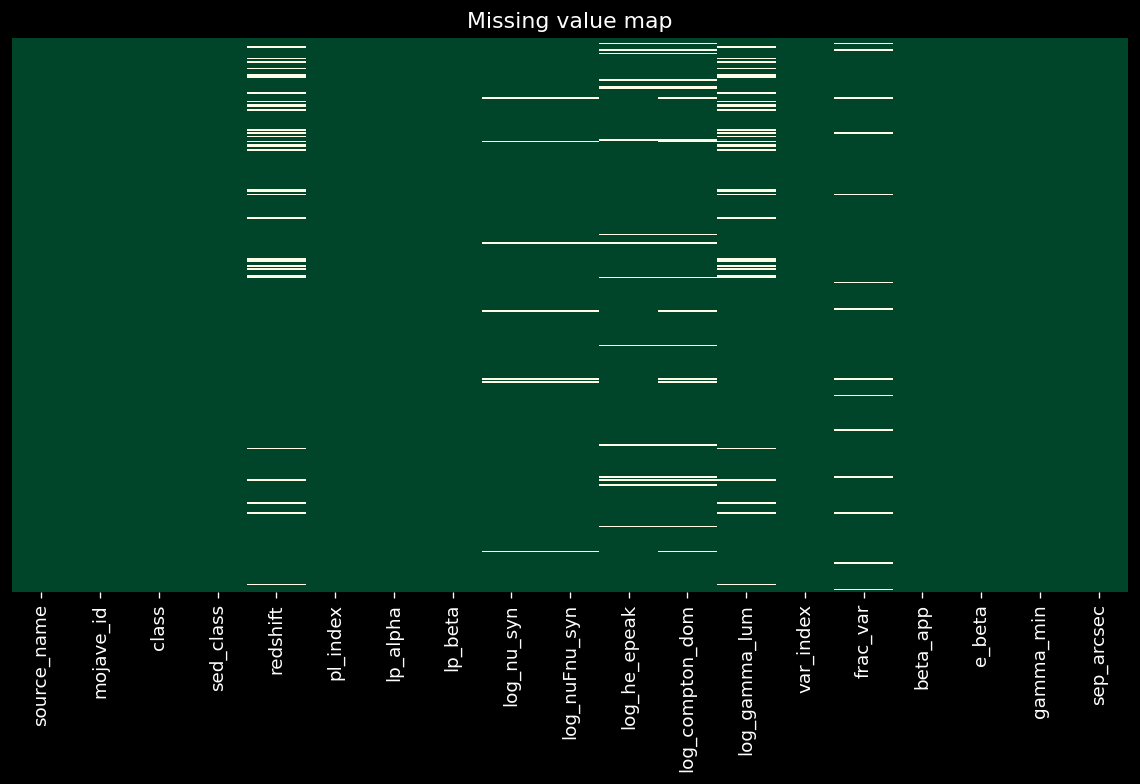

In [73]:
plt.figure(figsize=(12, 6))
sns.heatmap(matched_df.isnull(), cbar=False, yticklabels=False, cmap='YlGn_r')
plt.title('Missing value map')
plt.show()

## 7. Exploratory Data Analysis

In [31]:
# 7.1 Univariate distributions


In [32]:
# 7.2 BLL vs FSRQ pairplot


In [33]:
# 7.3 Blazar sequence: log_nu_syn vs log_compton_dom


In [34]:
# 7.4 Correlation matrix


## 8. Dimensionality Reduction: PCA and UMAP

**Feature set:** complete-case sources on core SED features: `pl_index`, `log_nu_syn`, `log_nuFnu_syn`, `log_compton_dom`, `var_index`. StandardScaler before both methods.

In [35]:
# 8.1 PCA


In [36]:
# 8.2 UMAP


## 9. Clustering: GMM and HDBSCAN

**Goal:** let the data reveal its own groupings without imposing BLL/FSRQ labels. Then compare to known classifications.


In [37]:
# 9.1 GMM


In [38]:
# 9.2 HDBSCAN


In [39]:
# 9.3 BCU probabilistic classification
